# ICA Conference Publications: Yearly Paper and Author Trends

This notebook analyzes the processed ICA conference publication data in `data/processed/` and focuses on three yearly trends:

1. Number of papers by year
2. Number of author records by year
3. Average number of authors per paper by year

## Data Definitions

- **Papers** are counted as distinct `Paper ID` values in `papers.csv`.
- **Authors** are counted from rows in `authors.csv`. This is an authorship-record count: the same person appearing on multiple papers is counted once per paper because the processed data does not include stable author IDs for reliable person-level deduplication.
- **Average authors per paper** uses the paper-level `Number of Authors` field in `papers.csv`. Four paper records have missing author counts and are excluded from that average.
- The processed data covers **2003 through 2018**.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Make paths work whether the notebook is run from the repo root or from notebooks/.
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "papers.csv").exists()
)
DATA_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

papers = pd.read_csv(DATA_DIR / "papers.csv")
authors = pd.read_csv(DATA_DIR / "authors.csv")

papers["Year"] = papers["Year"].astype(int)
authors["Year"] = authors["Year"].astype(int)
papers["Number of Authors"] = pd.to_numeric(papers["Number of Authors"], errors="coerce")

summary = (
    papers.groupby("Year")
    .agg(
        papers=("Paper ID", "nunique"),
        avg_authors_per_paper=("Number of Authors", "mean"),
        papers_with_author_counts=("Number of Authors", "count"),
    )
    .join(authors.groupby("Year").size().rename("author_records"))
    .reset_index()
)
summary["paper_yoy_pct"] = summary["papers"].pct_change() * 100
summary["author_yoy_pct"] = summary["author_records"].pct_change() * 100
summary["avg_authors_yoy_pct"] = summary["avg_authors_per_paper"].pct_change() * 100

summary.to_csv(NOTEBOOK_DIR / "yearly_trends_summary.csv", index=False)
summary

,Year,papers,avg_authors_per_paper,papers_with_author_counts,author_records,paper_yoy_pct,author_yoy_pct,avg_authors_yoy_pct
0,2003,994,1.777666,994,1767,NaN,NaN,NaN
1,2004,1099,1.805278,1099,1984,10.563380,12.280702,1.553246
2,2005,1224,1.819001,1221,2221,11.373976,11.945565,0.760176
3,2006,1120,1.856250,1120,2079,-8.496732,-6.393516,2.047783
4,2007,1865,1.662017,1864,3098,66.517857,49.013949,-10.463722
5,2008,1748,1.855835,1748,3244,-6.273458,4.712718,11.661617
6,2009,1918,1.770594,1918,3396,9.725400,4.685573,-4.593127
7,2010,1574,1.890089,1574,2975,-17.935349,-12.396938,6.748840
8,2011,2143,1.791881,2143,3840,36.149936,29.075630,-5.195967
9,2012,1995,1.870175,1995,3731,-6.906206,-2.838542,4.369426


## Summary of Annual Metrics

The dataset contains **27,466 paper records** and **54,316 author records** across 16 conference years. Paper and author volumes generally increase over the full period, but the series is not smooth: the most visible break is between **2013 and 2014**, when paper counts fall sharply before later recovering.


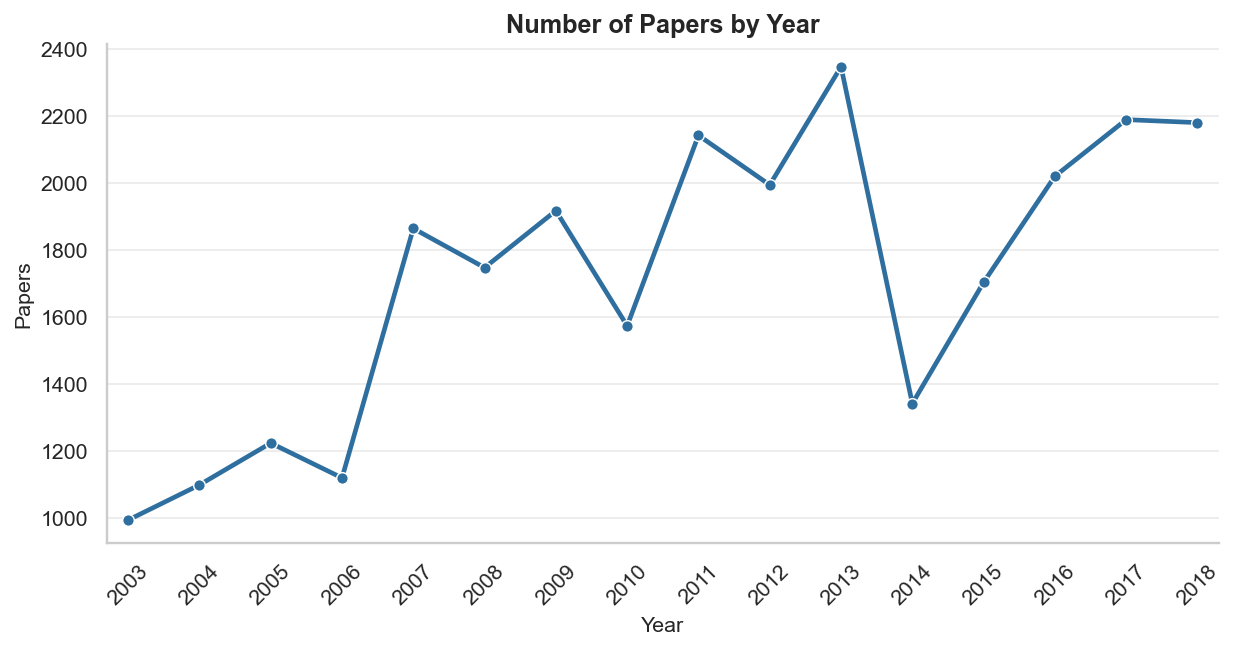

In [2]:
def line_plot(data, y, title, ylabel, filename, color="#1f77b4"):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.lineplot(data=data, x="Year", y=y, marker="o", linewidth=2.4, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(data["Year"])
    ax.tick_params(axis="x", rotation=45)
    ax.margins(x=0.02)
    ax.grid(True, axis="y", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    return fig, ax

fig, ax = line_plot(
    summary,
    "papers",
    "Number of Papers by Year",
    "Papers",
    "papers_by_year.png",
    color="#2f6f9f",
)
plt.show()

## Trend 1: Papers by Year

The number of papers rises from **994 in 2003** to a pre-2014 high of **2,348 in 2013**, an increase of about **136%**. Growth is uneven, with noticeable declines in 2006, 2008, 2010, and 2012, and a particularly large jump from **2006 to 2007**.

The sharpest discontinuity is from **2013 to 2014**, when the count drops from **2,348 to 1,342** (**-42.8%**). After that drop, the series recovers to **2,181 papers in 2018**, nearly matching 2017 but still below the 2013 peak.


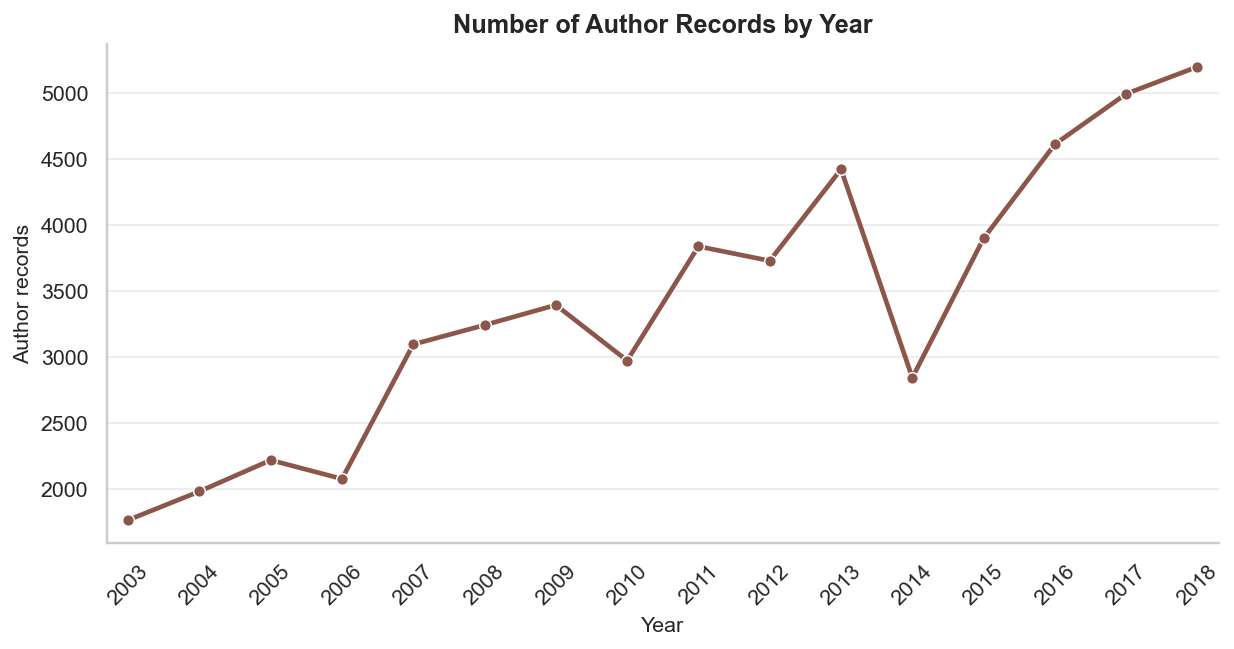

In [3]:
fig, ax = line_plot(
    summary,
    "author_records",
    "Number of Author Records by Year",
    "Author records",
    "authors_by_year.png",
    color="#8c564b",
)
plt.show()

## Trend 2: Authors by Year

Author records increase from **1,767 in 2003** to **4,424 in 2013**, a rise of about **150%**. Like the paper series, author records decline sharply in **2014**, falling to **2,845**.

The author series then rebounds more strongly than the paper series: by **2018**, it reaches **5,201 author records**, the highest value in the processed data. This means total authorship activity continues growing even after paper counts level off near 2017-2018.


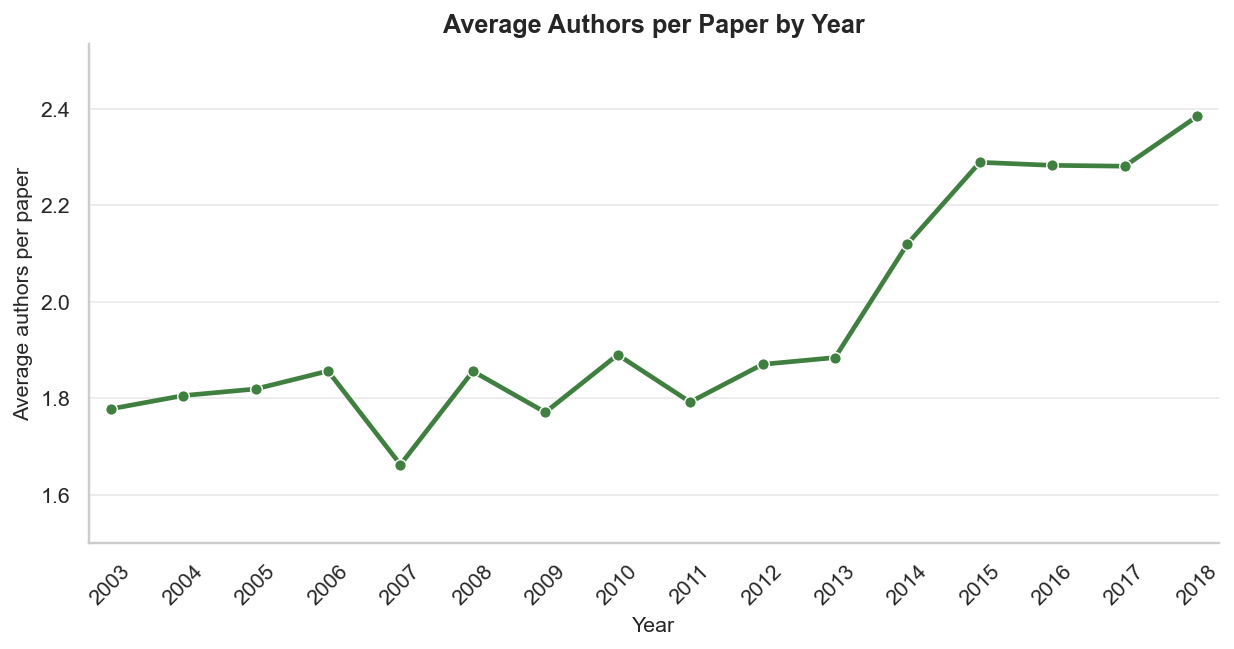

In [4]:
fig, ax = line_plot(
    summary,
    "avg_authors_per_paper",
    "Average Authors per Paper by Year",
    "Average authors per paper",
    "avg_authors_per_paper_by_year.png",
    color="#3f7f3f",
)
ax.set_ylim(1.5, max(summary["avg_authors_per_paper"]) + 0.15)
plt.show()

## Trend 3: Average Authors per Paper by Year

The average number of authors per paper stays near **1.8** for most years from **2003 through 2013**, with the lowest point at **1.66 in 2007**. Beginning in **2014**, the average shifts upward: **2.12 in 2014**, **2.29 in 2015**, and **2.38 in 2018**.

Across the full period, average authorship rises from **1.78 authors per paper in 2003** to **2.38 in 2018**, an increase of about **34%**. The later years therefore show more collaborative papers on average, even when paper counts are flat or slightly declining.


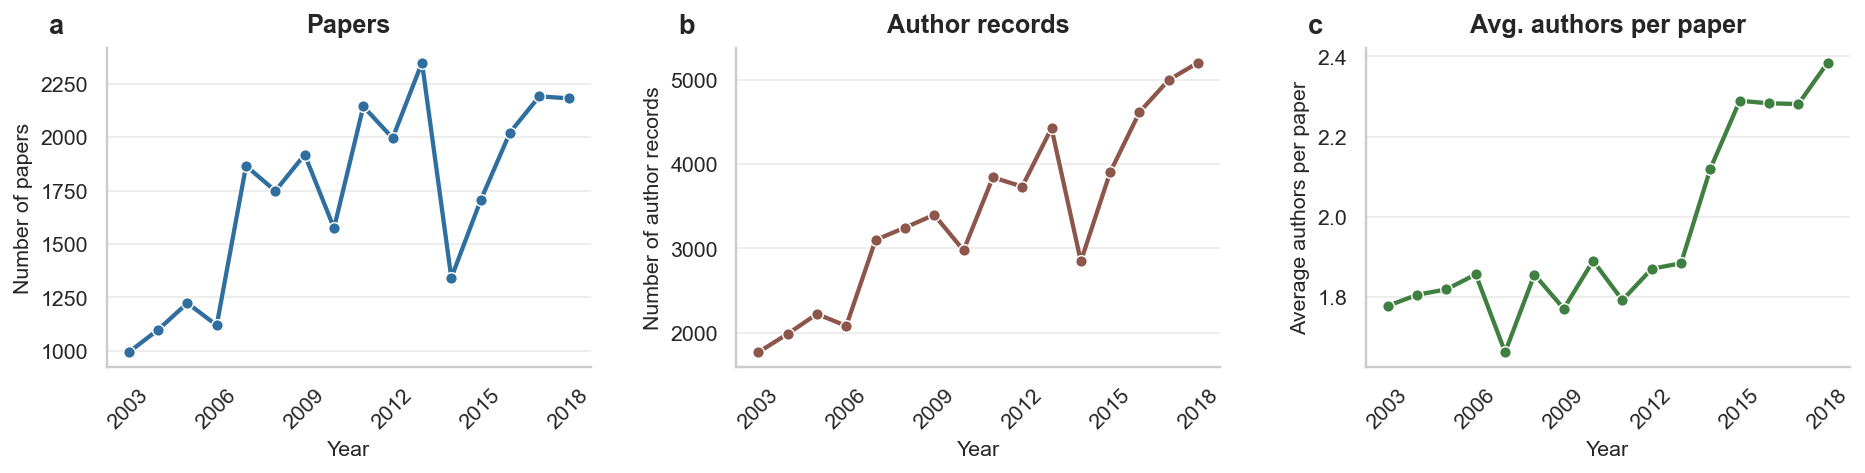

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharex=False)
plot_specs = [
    ("papers", "Papers", "Number of papers", "#2f6f9f", "a"),
    ("author_records", "Author records", "Number of author records", "#8c564b", "b"),
    ("avg_authors_per_paper", "Avg. authors per paper", "Average authors per paper", "#3f7f3f", "c"),
]
year_ticks = [2003, 2006, 2009, 2012, 2015, 2018]

for ax, (col, title, ylabel, color, panel_label) in zip(axes, plot_specs):
    sns.lineplot(data=summary, x="Year", y=col, marker="o", linewidth=2.2, color=color, ax=ax)
    ax.set_title(title, pad=8)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(year_ticks)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.35)
    ax.grid(False, axis="x")
    ax.text(
        -0.12,
        1.11,
        panel_label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="top",
    )
    sns.despine(ax=ax)

fig.tight_layout(w_pad=2.1)
fig.savefig(FIG_DIR / "combined_yearly_trends_horizontal.png", bbox_inches="tight", dpi=300)
fig.savefig(FIG_DIR / "combined_yearly_trends_horizontal.pdf", bbox_inches="tight")
plt.show()

## Overall Interpretation

The processed data shows long-run growth in conference publication volume and authorship activity from 2003 to 2018. Paper counts peak in 2013, drop in 2014, and then recover substantially by 2018. Author records also drop in 2014, but they exceed the earlier high by 2018.

The average-authors-per-paper trend is the clearest structural change: papers become more collaborative in the later years, moving from roughly two or fewer authors per paper before 2014 to more than two authors per paper afterward. Because this analysis uses processed files only, the 2013-2014 discontinuity should be interpreted as an observed data break unless confirmed against collection or conference-program changes.
